In [1]:
from models.mc import hybridMonteCarlo
from models.pso import PSO_Numpy


import numpy as np
import matplotlib.pyplot as plt
import time

In [19]:
S0, r, sigma, T, nPath, nPeriod, K, opttype, nFish = 100.0, 0.03, 0.3, 1.0, 5, 10, 110.0, 'P', 2  
mc = hybridMonteCarlo(S0, r, sigma, T, nPath, nPeriod, K, opttype, nFish)
print(f'{nPath} paths, {nPeriod} periods, {nFish} particles.\n')
print(f'St in shape {mc.St.shape}')

5 paths, 10 periods, 2 particles.

St in shape (5, 10)


In [20]:
mc.St

array([[109.08399 , 107.536026,  96.75502 , 108.35443 ,  93.66288 ,
         90.33175 ,  90.94851 ,  85.19112 ,  82.58097 ,  87.71651 ],
       [100.819885, 123.0755  , 120.87096 , 120.084206, 134.07718 ,
        147.67532 , 167.71375 , 163.32869 , 173.56146 , 156.85498 ],
       [ 97.093   ,  91.551834,  95.19889 , 106.15536 , 104.167076,
        103.32737 , 113.08027 , 106.48209 , 120.35926 , 101.22447 ],
       [ 97.54597 ,  97.839066,  96.105576,  92.156   ,  84.79755 ,
         70.80885 ,  65.27132 ,  68.304924,  71.15402 ,  84.73045 ],
       [107.13865 , 125.25514 , 116.53838 , 107.09523 , 105.51695 ,
        110.39421 , 107.79472 , 105.280136, 115.806946, 111.379425]],
      dtype=float32)

In [21]:
pso_np = PSO_Numpy(mc, nFish)
pso = pso_np.position.T + 30
pso

array([[ 91.576294,  81.95436 ,  85.029236,  69.80597 ,  54.375244,
        119.60113 ,  41.715694, 128.27875 ,  78.94832 , 106.510315],
       [ 87.42263 ,  30.638954, 126.83384 ,  31.58374 , 124.64503 ,
         77.37869 ,  37.88077 ,  36.445595,  70.90067 ,  37.251446]],
      dtype=float32)

In [15]:
cross_mask = pso > mc.St
cross_mask

array([[False, False, False, False, False,  True, False, False, False,
         True],
       [False, False, False, False, False, False, False, False, False,
        False],
       [False, False, False, False, False,  True, False, False, False,
         True],
       [False, False, False, False,  True,  True,  True, False, False,
         True],
       [False, False, False, False, False,  True, False, False, False,
         True]])

In [16]:
mc.St[cross_mask]

array([ 90.33175 ,  87.71651 , 103.32737 , 101.22447 ,  84.79755 ,
        70.80885 ,  65.27132 ,  84.73045 , 110.39421 , 111.379425],
      dtype=float32)

In [17]:
def get_topmost(ar: np.ndarray):
    return [(row.index(True), i) for i, row in enumerate(ar.T.tolist()) if True in row]

get_topmost(cross_mask)

[(3, 4), (0, 5), (3, 6), (0, 9)]

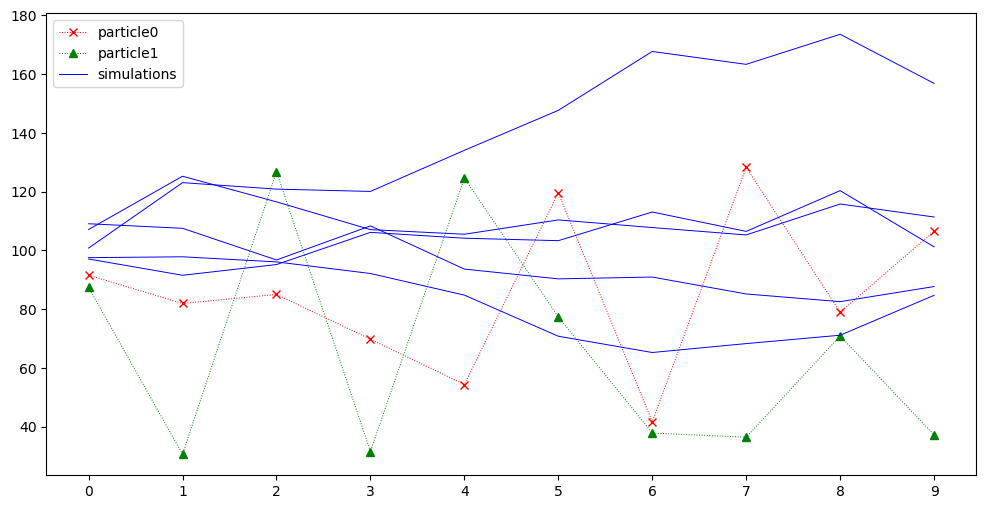

In [22]:
fig = plt.figure(figsize=(12,6))

# plt.scatter(np.arange(0, len(pso_np.position), 1), pso[0], marker='x', color='r', )
# plt.scatter(np.arange(0, len(pso_np.position), 1), pso[1], marker='^', color='g', )
plt.plot(np.arange(0, len(pso_np.position), 1), pso[0], marker='x', color='r', lw=.7, linestyle='dotted')
plt.plot(np.arange(0, len(pso_np.position), 1), pso[1], marker='^', color='g', lw=.7, linestyle='dotted')
plt.plot(mc.St.T, 'b', lw=.7,)
plt.xticks(np.arange(0, len(pso_np.position), 1))
plt.legend(['particle0', 'particle1', 'simulations',])
plt.show()